# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [1]:
import os
from pathlib import Path

import ranking

# Cargamos el corpus: books1000, que es un corpus compuesto por 1000 libros de Gutenberg Project
path_corpus_gutenberg1000 = Path("data/gutenberg/books1000")
books1000 = os.listdir(path_corpus_gutenberg1000)

corpusbooks1000 = []

for archivo in books1000:
    path_archivo = path_corpus_gutenberg1000/archivo
    with open(path_archivo, "r", encoding="utf-8") as f:
        contenido = f.read()
        corpusbooks1000.append(contenido)

print(f"Número de libros en el corpus: {len(corpusbooks1000)}")

Número de libros en el corpus: 1000


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [6]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 1. Matriz TF y DF
tf_vec = CountVectorizer(max_features=5000, stop_words="english")
tf_matrix = tf_vec.fit_transform(corpusbooks1000)
vocab = tf_vec.get_feature_names_out()

df_values = (tf_matrix > 0).sum(axis=0).A1  # cuántos docs tienen el término

# 2. TF-IDF
tfidf_vec = TfidfVectorizer(vocabulary=vocab,max_features=5000, stop_words="english")
tfidf_matrix = tfidf_vec.fit_transform(corpusbooks1000)

# 3. DataFrame comparativo
df_result = pd.DataFrame({
    "term"      : vocab,
    "total_tf"  : tf_matrix.sum(axis=0).A1.astype(int),
    "df"        : df_values.astype(int),
    "mean_tfidf": tfidf_matrix.mean(axis=0).A1.round(6)
}).sort_values("mean_tfidf", ascending=False).reset_index(drop=True)

print(df_result.head(20))

         term  total_tf    df  mean_tfidf
0        said    247865   925    0.137292
1   gutenberg     98462  1000    0.129992
2     project     90289  1000    0.117897
3         man    162660   947    0.094955
4        work     89544  1000    0.084150
5        like    124931   932    0.080320
6        time    129150   947    0.074586
7      little    111391   928    0.073796
8         did     99452   922    0.061414
9       great    100215   930    0.057256
10       good     96141   931    0.055655
11        day     92798   932    0.054844
12        old     86783  1000    0.054038
13         mr     91696   731    0.053313
14       know     87603  1000    0.052605
15        men     85359   923    0.050700
16       came     78087   908    0.049905
17       come     86956  1000    0.047776
18      works     41776  1000    0.047203
19       life     76807  1000    0.046307


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [7]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

#1. Vector de consulta

query = "freedom and liberty"
query_vec = tfidf_vec.transform([query]) # Transformar la consulta al espacio TF-IDF

#2. Similitud coseno entre la consulta y cada documento(todos)
similitudes = cosine_similarity(query_vec, tfidf_matrix).flatten()

#3. Ranking documentos ordenados por relevancia
ranking_idx = np.argsort(similitudes)[::-1]

df_ranking = pd.DataFrame({
    "documento": [books1000[i] for i in ranking_idx],
    "similitud": similitudes[ranking_idx]
})

df_ranking.head(10) # top 10 de docs

,documento,similitud
0,pg34901.txt,0.179013
1,pg925.txt,0.117795
2,pg690.txt,0.101974
3,pg585.txt,0.079430
4,pg444.txt,0.077629
5,pg722.txt,0.064874
6,pg608.txt,0.064672
7,pg992.txt,0.064226
8,pg712.txt,0.062103
9,pg815.txt,0.061101


## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [11]:
import numpy as np
from collections import Counter
import re

#1. Tokenización
def tokenizar(texto):
    return re.findall(r'\b[a-z]+\b', texto.lower())

corpus_tokens = [tokenizar(doc) for doc in corpusbooks1000]

# 2. Longitudes de documentos y promedio
longitudes = np.array([len(doc) for doc in corpus_tokens])
avgdl = longitudes.mean()

#3. TF por documento
tf_docs = [Counter(doc) for doc in corpus_tokens]

#4. DF e IDF de BM25
N = len(corpus_tokens)
df_bm25 = Counter()

for doc in corpus_tokens:
    for term in set(doc):
        df_bm25[term] += 1

def idf_bm25(term):
    df = df_bm25.get(term, 0)
    return np.log((N - df + 0.5) / (df + 0.5) + 1)

#5. Parámetros BM25
k1 = 1.5   # controla saturación del TF
b  = 0.75  # controla normalización por longitud

#6. Score BM25 para un documento
def score_bm25(query_terms, doc_idx):
    tf   = tf_docs[doc_idx]
    dl   = longitudes[doc_idx]
    score = 0
    for term in query_terms:
        f = tf.get(term, 0)
        idf = idf_bm25(term)
        numerador   = f * (k1 + 1)
        denominador = f + k1 * (1 - b + b * dl / avgdl)
        score += idf * (numerador / denominador)
    return score

#7. Score para toda la colección
def ranking_bm25(query):
    query_terms = tokenizar(query)
    scores = [score_bm25(query_terms, i) for i in range(N)]
    return scores

#8. Ranking
query = "freedom and liberty"
scores_bm25 = ranking_bm25(query)

nombres_docs = os.listdir(path_corpus_gutenberg1000)

ranking_bm25_df = pd.DataFrame({
    "documento": nombres_docs,
    "bm25_score": scores_bm25
}).sort_values("bm25_score", ascending=False).reset_index(drop=True)

ranking_bm25_df.index += 1

#Comparación TF-IDF vs BM25
top_tfidf = df_ranking.head(10).reset_index(drop=True)
top_bm25  = ranking_bm25_df.head(10).reset_index(drop=True)

comparacion = pd.DataFrame({
    "# " : range(1, 11),
    "TF-IDF doc"  : top_tfidf["documento"],
    "TF-IDF score": top_tfidf["similitud"].round(4),
    "BM25 doc"    : top_bm25["documento"],
    "BM25 score"  : top_bm25["bm25_score"].round(4),
})

print(f"Consulta: '{query}'\n")
print(comparacion.to_string(index=False))

Consulta: 'freedom and liberty'

 #   TF-IDF doc  TF-IDF score    BM25 doc  BM25 score
  1 pg34901.txt        0.1790   pg925.txt      2.2283
  2   pg925.txt        0.1178 pg34901.txt      2.2266
  3   pg690.txt        0.1020   pg690.txt      2.2140
  4   pg585.txt        0.0794   pg815.txt      2.2051
  5   pg444.txt        0.0776   pg585.txt      2.1847
  6   pg722.txt        0.0649   pg992.txt      2.1842
  7   pg608.txt        0.0647 pg23321.txt      2.1739
  8   pg992.txt        0.0642   pg816.txt      2.1711
  9   pg712.txt        0.0621   pg712.txt      2.1683
 10   pg815.txt        0.0611 pg25821.txt      2.1665


## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

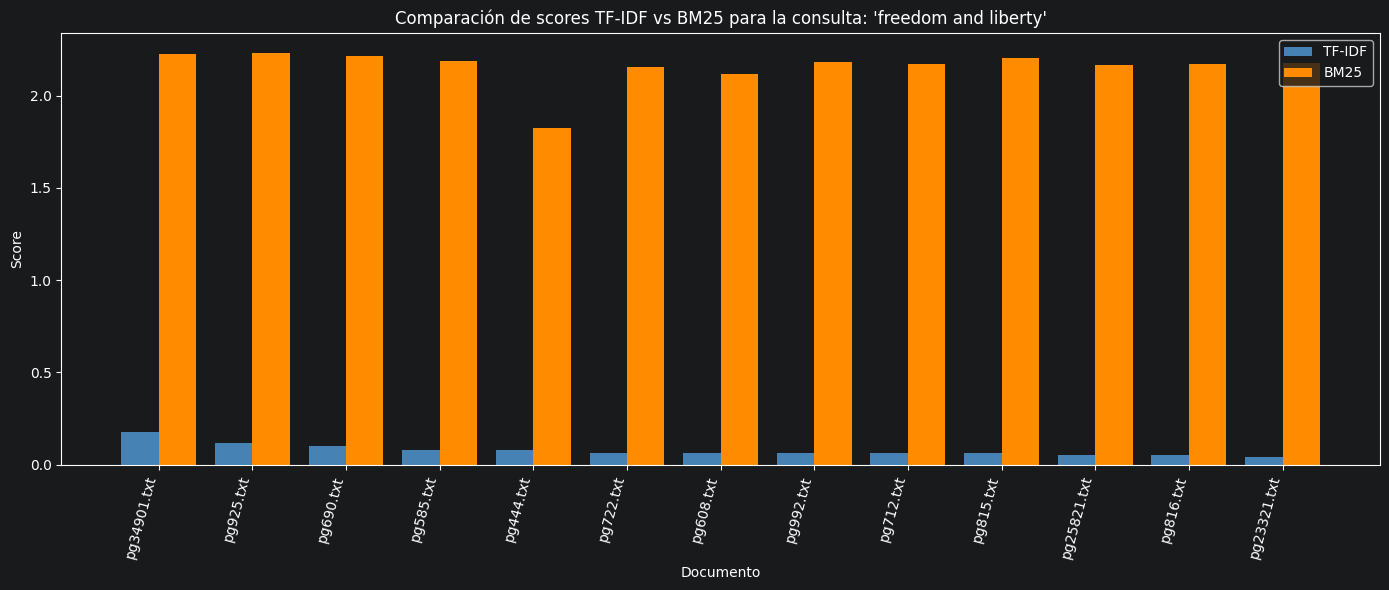

In [16]:
import matplotlib.pyplot as plt

top_n = 10

tfidf_scores_df = df_ranking.head(top_n).copy()
tfidf_scores_df = tfidf_scores_df.rename(columns={"similitud": "tfidf_score"})

bm25_scores_df = ranking_bm25_df.head(top_n).copy()


docs_comparar = pd.Index(tfidf_scores_df["documento"]).union(bm25_scores_df["documento"])

df_scores_comparacion = pd.DataFrame({"documento": docs_comparar})
df_scores_comparacion = df_scores_comparacion.merge(
    df_ranking[["documento", "similitud"]].rename(columns={"similitud": "tfidf_score"}),
    on="documento",
    how="left"
)
df_scores_comparacion = df_scores_comparacion.merge(
    ranking_bm25_df[["documento", "bm25_score"]],
    on="documento",
    how="left"
)

df_scores_comparacion[["tfidf_score", "bm25_score"]] = df_scores_comparacion[
    ["tfidf_score", "bm25_score"]
].fillna(0)

df_scores_comparacion = df_scores_comparacion.sort_values(
    ["tfidf_score", "bm25_score"],
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(14, 6))

x = np.arange(len(df_scores_comparacion))
width = 0.4

plt.bar(
    x - width / 2,
    df_scores_comparacion["tfidf_score"],
    width,
    label="TF-IDF",
    color="steelblue"
)

plt.bar(
    x + width / 2,
    df_scores_comparacion["bm25_score"],
    width,
    label="BM25",
    color="darkorange"
)

plt.title(f"Comparación de scores TF-IDF vs BM25 para la consulta: '{query}'")
plt.xlabel("Documento")
plt.ylabel("Score")
plt.xticks(
    x,
    df_scores_comparacion["documento"],
    rotation=75,
    ha="right"
)
plt.legend()
plt.tight_layout()
plt.show()


Al comparar los rankings, se observa que TF-IDF presenta mayor variabilidad en los scores, destacando documentos con alta frecuencia de términos específicos. En cambio, BM25 produce valores más homogéneos debido a la normalización por longitud y la saturación de frecuencia. Algunos documentos como “pg34901.txt” obtienen mayor relevancia en TF-IDF, mientras que otros como “pg9815.txt” destacan más en BM25. Estas diferencias se deben a que BM25 ajusta mejor la frecuencia de términos y penaliza documentos largos, proporcionando un ranking más equilibrado